In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/ML/Proj/credit_risk_dataset.csv', encoding='latin-1')

In [6]:
df.shape

(32581, 12)

In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
df.describe(include="object")

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [10]:
missing = df.isnull().sum()
missing

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [11]:
df.duplicated().sum()

np.int64(165)

In [12]:
df.shape

(32581, 12)

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns
list(numeric_cols)

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [16]:
categorical_cols = df.select_dtypes(include="object").columns
list(categorical_cols)

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


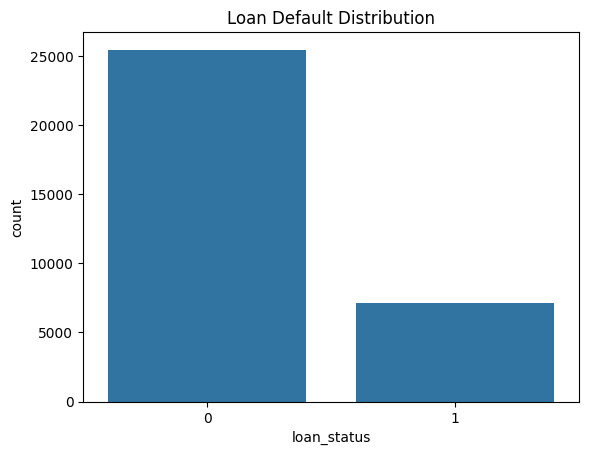

In [27]:
print(df["loan_status"].value_counts())
print(df["loan_status"].value_counts(normalize=True) * 100)
sns.countplot(data=df, x="loan_status")
plt.title("Loan Default Distribution")
plt.show()

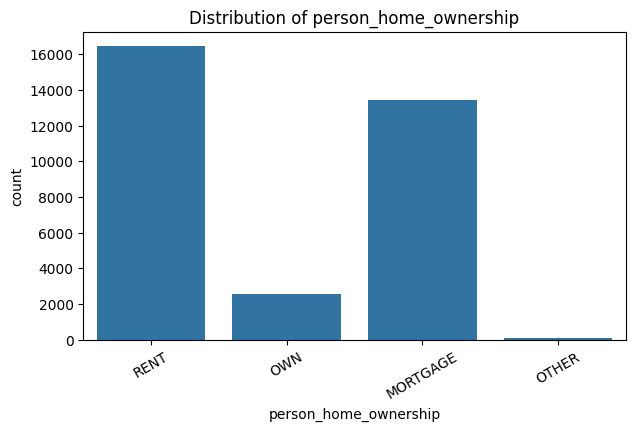

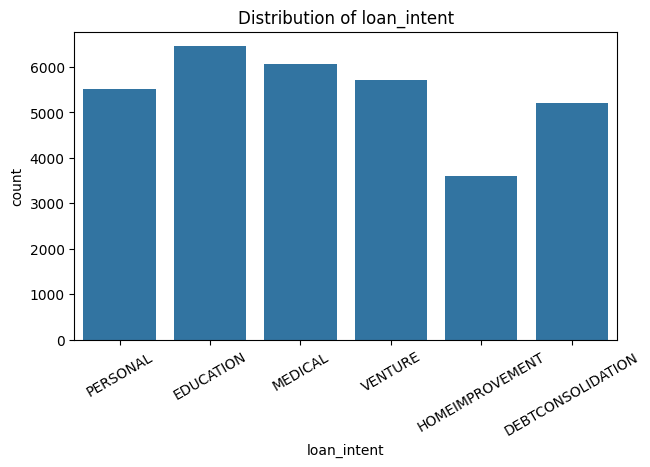

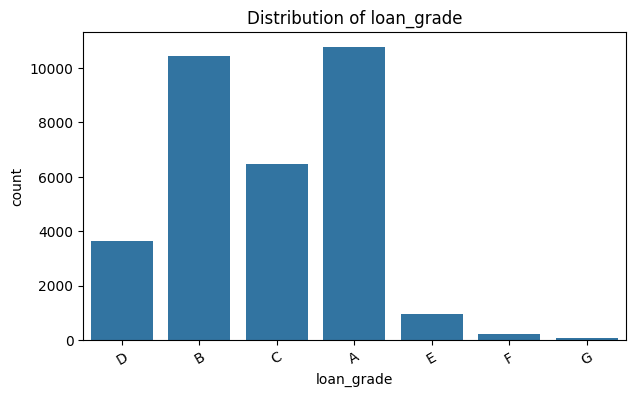

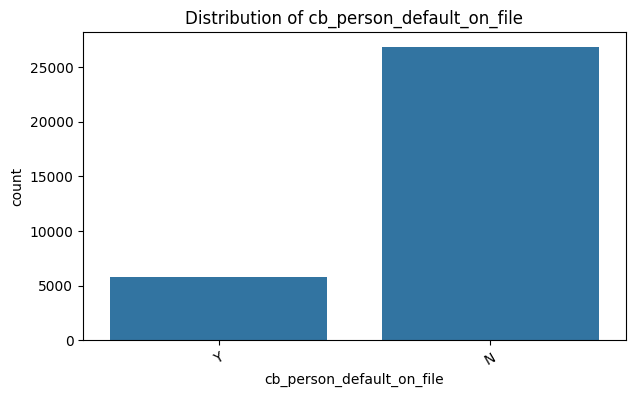

In [22]:
for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()

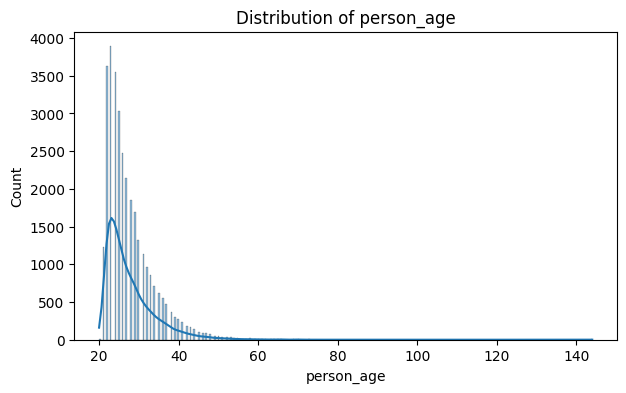

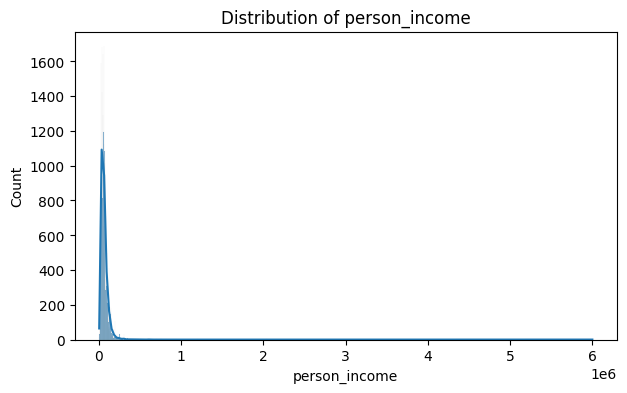

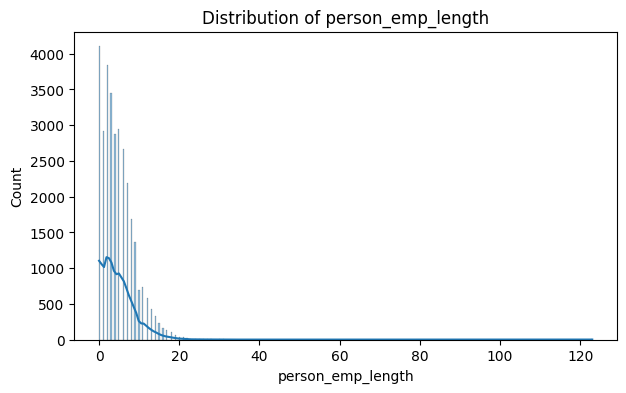

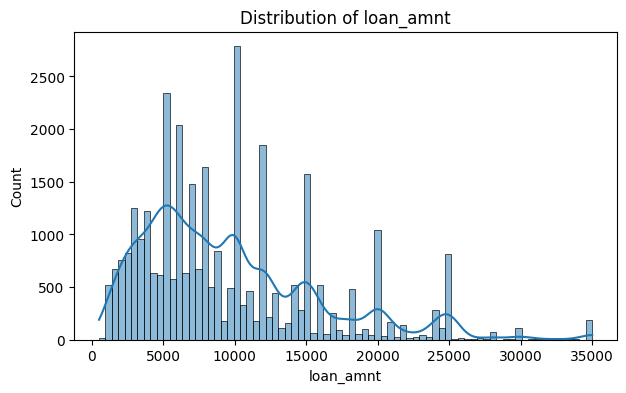

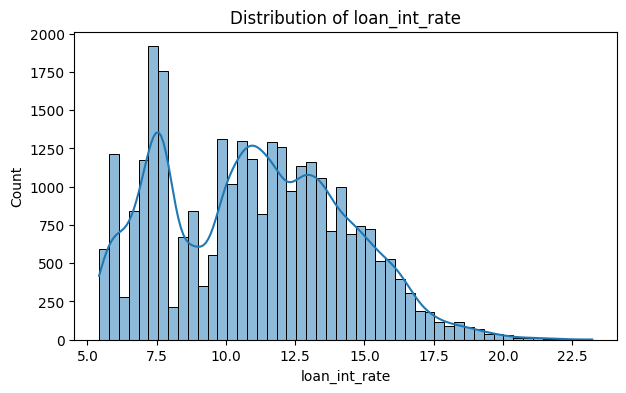

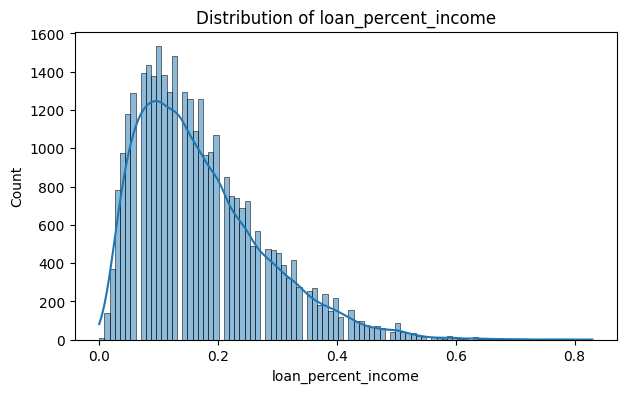

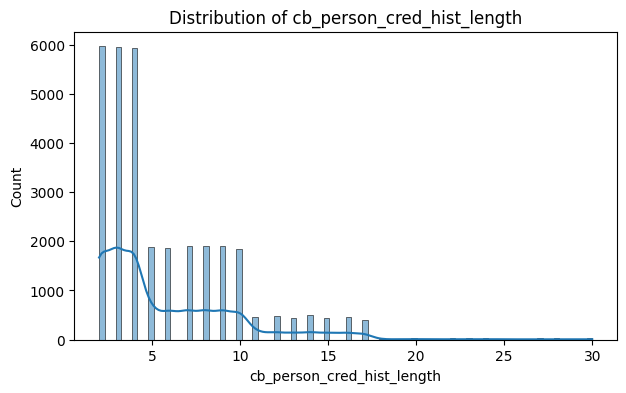

In [23]:
numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

for col in numeric_features:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

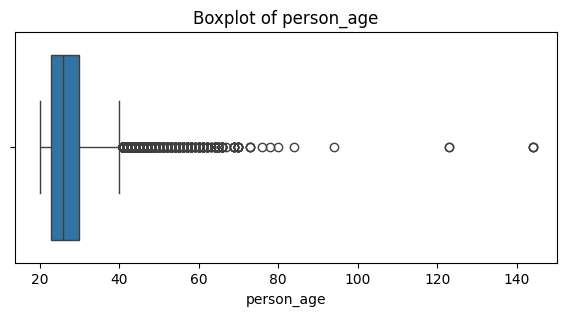

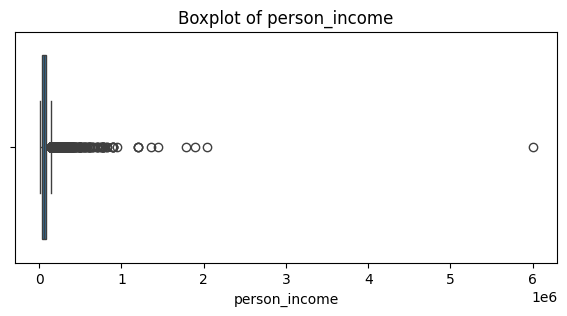

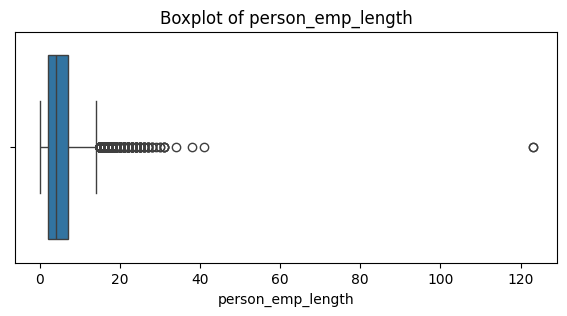

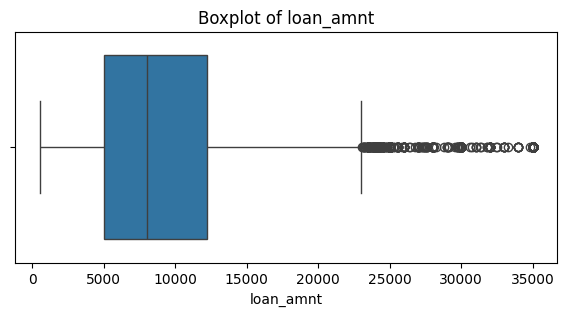

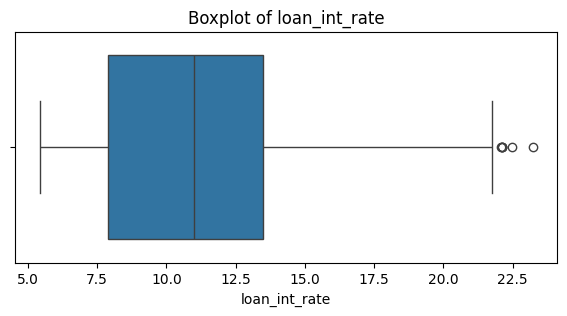

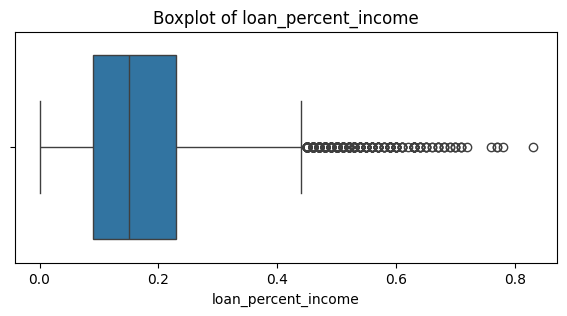

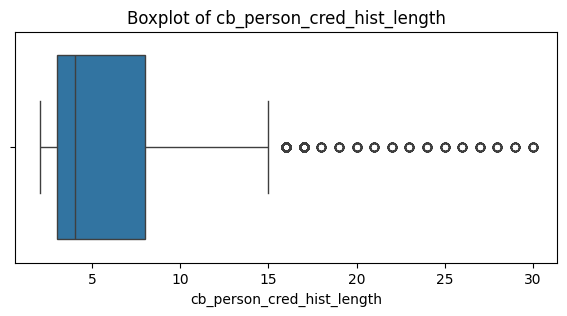

In [24]:
for col in numeric_features:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

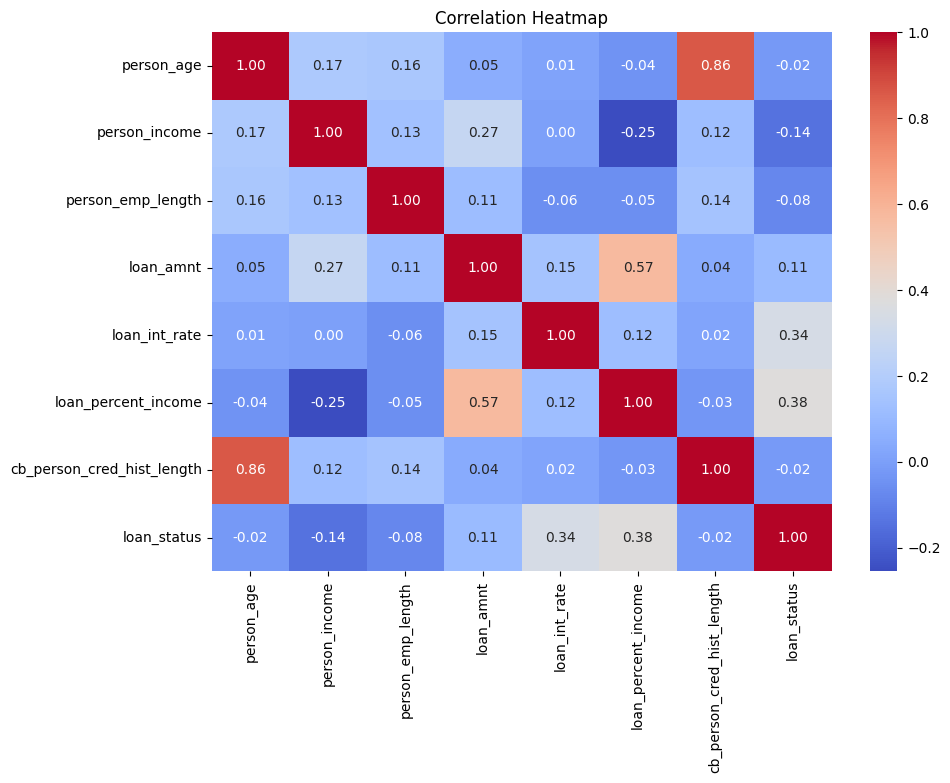

In [25]:
plt.figure(figsize=(10,7))

corr = df[numeric_features + ["loan_status"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

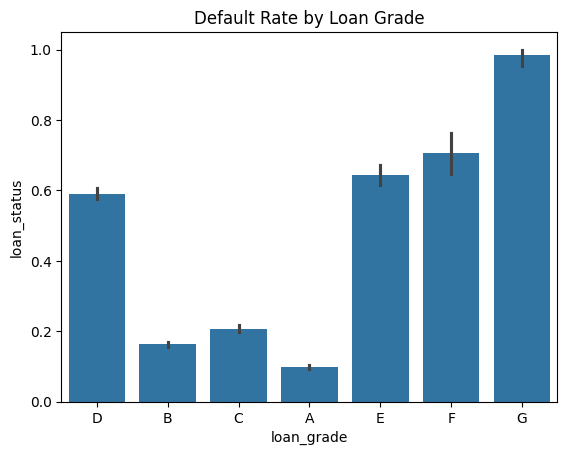

In [28]:
sns.barplot(data=df, x="loan_grade", y="loan_status")
plt.title("Default Rate by Loan Grade")
plt.show()

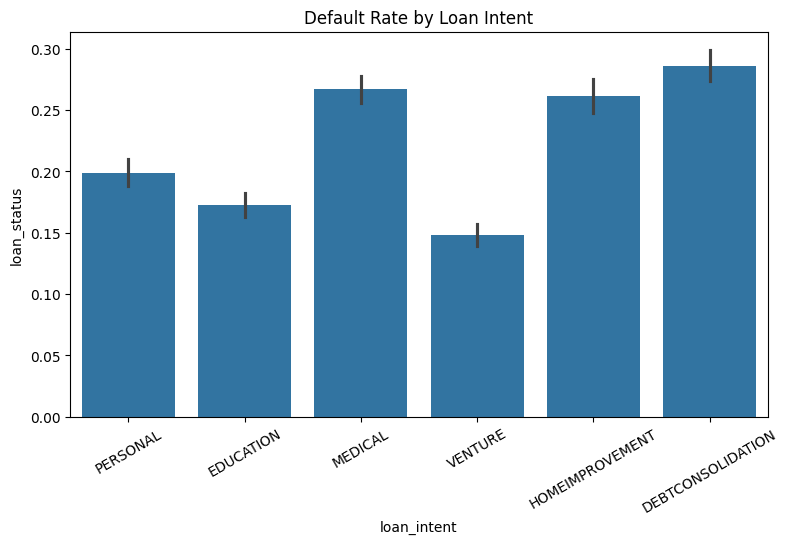

In [29]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="loan_intent", y="loan_status")
plt.title("Default Rate by Loan Intent")
plt.xticks(rotation=30)
plt.show()

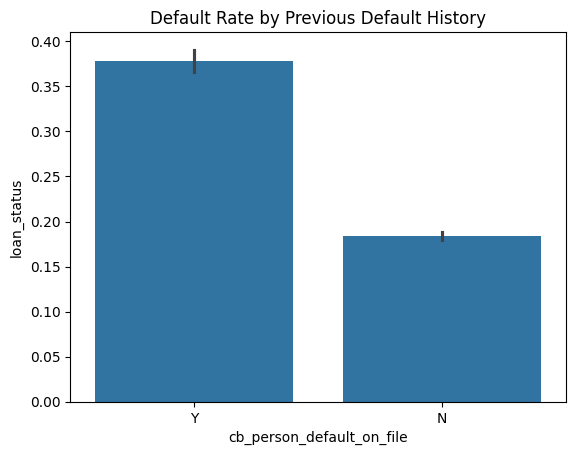

In [30]:
sns.barplot(
    data=df,
    x="cb_person_default_on_file",
    y="loan_status"
)

plt.title("Default Rate by Previous Default History")
plt.show()

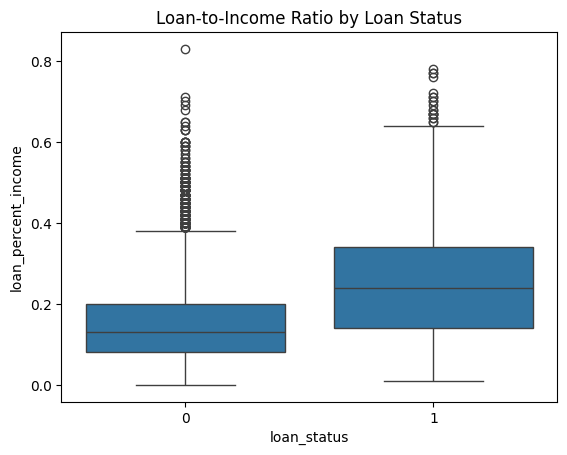

In [31]:
sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_percent_income"
)

plt.title("Loan-to-Income Ratio by Loan Status")
plt.show()

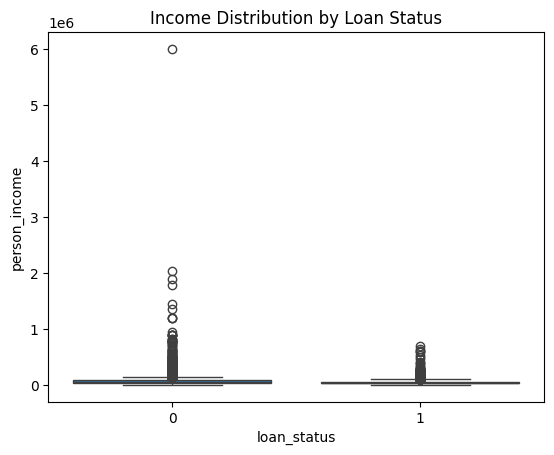

In [32]:
sns.boxplot(
    data=df,
    x="loan_status",
    y="person_income"
)

plt.title("Income Distribution by Loan Status")
plt.show()